In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv("house.csv")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [6]:
df.drop(columns={"id"},inplace=True)

In [7]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [9]:
df["floors"].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


<Axes: xlabel='waterfront', ylabel='price'>

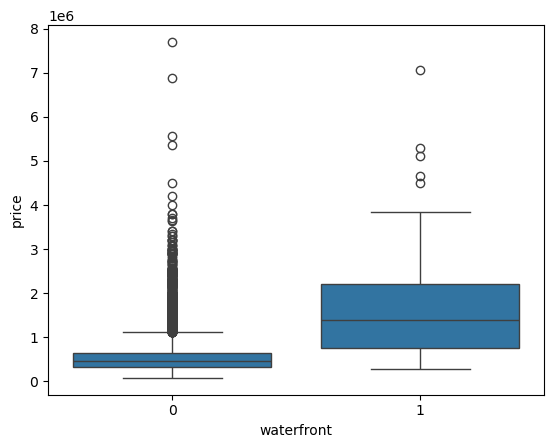

In [16]:
sns.boxplot(x=df["waterfront"], y=df["price"])

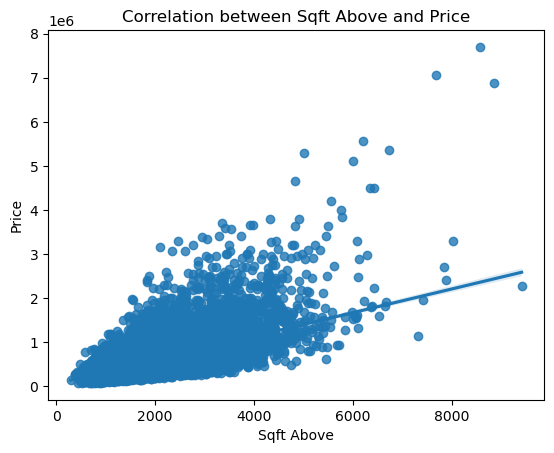

In [18]:
sns.regplot(x='sqft_above', y='price', data=df)

plt.title("Correlation between Sqft Above and Price")
plt.xlabel("Sqft Above")
plt.ylabel("Price")
plt.show()

In [19]:
from sklearn.linear_model import LinearRegression

X = df[['sqft_living']]
Y = df['price']

lm = LinearRegression()
lm.fit(X, Y)

r2 = lm.score(X, Y)
print("R²:", r2)

R²: 0.4928532179037932


In [20]:
features = ['floors',
            'waterfront',
            'lat',
            'bedrooms',
            'sqft_basement',
            'view',
            'bathrooms',
            'sqft_living15',
            'sqft_above',
            'grade',
            'sqft_living']

X = df[features]
Y = df['price']

lm = LinearRegression()
lm.fit(X, Y)

print("R²:", lm.score(X, Y))

R²: 0.6577151058279322


In [22]:
Input = [('scale', StandardScaler()),
         ('model', LinearRegression())]

pipe = Pipeline(Input)

pipe.fit(X, Y)

print("R²:", pipe.score(X, Y))

R²: 0.6577151058279325


In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1
)

RidgeModel = Ridge(alpha=0.1)

RidgeModel.fit(X_train, Y_train)

print("Test R²:", RidgeModel.score(X_test, Y_test))

Test R²: 0.6460194468601677


In [26]:
pr = PolynomialFeatures(degree=2)

X_train_pr = pr.fit_transform(X_train)
X_test_pr = pr.transform(X_test)

RidgeModel = Ridge(alpha=0.1)

RidgeModel.fit(X_train_pr, Y_train)

print("Polynomial Ridge Test R²:", RidgeModel.score(X_test_pr, Y_test))

Polynomial Ridge Test R²: 0.7546208826821221
